In [1]:
import numpy as np
import pandas as pd
from faker import Faker
import random
from datetime import datetime, timedelta
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

fake = Faker()
np.random.seed(42)
random.seed(42)

In [2]:
N_USERS = 10000

user_types = np.random.choice(
    ['fashion_shopper', 'electronics_buyer', 'hybrid'],
    size=N_USERS,
    p=[0.45, 0.35, 0.20]
)

users = pd.DataFrame({
    'user_id': [f'U{str(i).zfill(5)}' for i in range(N_USERS)],
    'user_type': user_types,
    'age': np.random.randint(18, 65, size=N_USERS),
    'price_sensitivity': np.random.uniform(0.1, 1.0, size=N_USERS),
    'session_frequency': np.random.randint(1, 30, size=N_USERS),
    'location': [fake.state() for _ in range(N_USERS)],
    'signup_date': [
        fake.date_between(start_date='-3y', end_date='-6m')
        for _ in range(N_USERS)
    ]
})

print(users.shape)
print(users['user_type'].value_counts())

(10000, 7)
user_type
fashion_shopper      4582
electronics_buyer    3456
hybrid               1962
Name: count, dtype: int64


In [3]:
N_FASHION = 500
N_ELECTRONICS = 300

fashion_products = pd.DataFrame({
    'product_id': [f'F{str(i).zfill(4)}' for i in range(N_FASHION)],
    'category': 'fashion',
    'subcategory': np.random.choice(
        ['tops', 'bottoms', 'shoes', 'accessories', 'outerwear'],
        size=N_FASHION,
        p=[0.25, 0.25, 0.20, 0.15, 0.15]
    ),
    'price': np.random.uniform(15, 300, size=N_FASHION).round(2),
    'season': np.random.choice(
        ['spring', 'summer', 'fall', 'winter', 'all_season'],
        size=N_FASHION,
        p=[0.20, 0.25, 0.20, 0.25, 0.10]
    )
})

electronics_products = pd.DataFrame({
    'product_id': [f'E{str(i).zfill(4)}' for i in range(N_ELECTRONICS)],
    'category': 'electronics',
    'subcategory': np.random.choice(
        ['laptops', 'phones', 'tablets', 'accessories', 'audio'],
        size=N_ELECTRONICS,
        p=[0.20, 0.25, 0.15, 0.25, 0.15]
    ),
    'price': np.random.uniform(20, 1500, size=N_ELECTRONICS).round(2),
    'season': 'all_season'
})

products = pd.concat([fashion_products, electronics_products], ignore_index=True)

print(products.shape)
print(products['category'].value_counts())
print(products['price'].describe())

(800, 5)
category
fashion        500
electronics    300
Name: count, dtype: int64
count     800.000000
mean      370.456037
std       391.385079
min        15.970000
25%       111.810000
50%       215.595000
75%       434.927500
max      1495.870000
Name: price, dtype: float64


In [4]:
def get_seasonal_multiplier(date, user_type):
    month = date.month

    if user_type == 'fashion_shopper':
        # Fashion buys spike in summer (Jun-Aug) and winter (Nov-Jan)
        if month in [6, 7, 8]:
            return np.random.uniform(1.8, 2.5)
        elif month in [11, 12, 1]:
            return np.random.uniform(1.6, 2.2)
        elif month in [3, 4, 5]:
            return np.random.uniform(0.8, 1.2)
        else:
            return np.random.uniform(0.6, 1.0)

    elif user_type == 'electronics_buyer':
        # Electronics spike before holidays and back-to-school
        if month in [11, 12]:
            return np.random.uniform(2.0, 3.0)
        elif month in [8, 9]:
            return np.random.uniform(1.5, 2.0)
        else:
            return np.random.uniform(0.5, 1.0)

    else:  # hybrid
        return np.random.uniform(0.8, 1.5)

# Test it
test_date = datetime(2024, 12, 1)
print(f"Fashion in December: {get_seasonal_multiplier(test_date, 'fashion_shopper'):.2f}")
print(f"Electronics in December: {get_seasonal_multiplier(test_date, 'electronics_buyer'):.2f}")
print(f"Fashion in March: {get_seasonal_multiplier(datetime(2024, 3, 1), 'fashion_shopper'):.2f}")
print(f"Electronics in March: {get_seasonal_multiplier(datetime(2024, 3, 1), 'electronics_buyer'):.2f}")

Fashion in December: 1.71
Electronics in December: 2.56
Fashion in March: 0.84
Electronics in March: 0.59


In [5]:
N = 200000

# Vectorized — no loops
user_sample = users.sample(N, replace=True).reset_index(drop=True)
date_offsets = np.random.randint(0, (datetime(2024, 12, 31) - datetime(2023, 1, 1)).days, size=N)
dates = [datetime(2023, 1, 1) + timedelta(days=int(d)) for d in date_offsets]
months = np.array([d.month for d in dates])

# Assign products based on user type
fashion_ids = products[products['category'] == 'fashion']['product_id'].values
electronics_ids = products[products['category'] == 'electronics']['product_id'].values
all_ids = products['product_id'].values

product_ids = np.where(
    user_sample['user_type'] == 'fashion_shopper',
    np.random.choice(fashion_ids, size=N),
    np.where(
        user_sample['user_type'] == 'electronics_buyer',
        np.random.choice(electronics_ids, size=N),
        np.random.choice(all_ids, size=N)
    )
)

# Seasonal multipliers vectorized
def vectorized_seasonal(months, user_types):
    mult = np.ones(N)
    fashion_mask = user_types == 'fashion_shopper'
    elec_mask = user_types == 'electronics_buyer'

    # Fashion
    mult[fashion_mask & np.isin(months, [6,7,8])] = np.random.uniform(1.8, 2.5, fashion_mask[fashion_mask & np.isin(months, [6,7,8])].sum())
    mult[fashion_mask & np.isin(months, [11,12,1])] = np.random.uniform(1.6, 2.2, fashion_mask[fashion_mask & np.isin(months, [11,12,1])].sum())
    mult[fashion_mask & np.isin(months, [3,4,5])] = np.random.uniform(0.8, 1.2, fashion_mask[fashion_mask & np.isin(months, [3,4,5])].sum())
    mult[fashion_mask & np.isin(months, [2,9,10])] = np.random.uniform(0.6, 1.0, fashion_mask[fashion_mask & np.isin(months, [2,9,10])].sum())

    # Electronics
    mult[elec_mask & np.isin(months, [11,12])] = np.random.uniform(2.0, 3.0, elec_mask[elec_mask & np.isin(months, [11,12])].sum())
    mult[elec_mask & np.isin(months, [8,9])] = np.random.uniform(1.5, 2.0, elec_mask[elec_mask & np.isin(months, [8,9])].sum())
    mult[elec_mask & ~np.isin(months, [8,9,11,12])] = np.random.uniform(0.5, 1.0, (elec_mask & ~np.isin(months, [8,9,11,12])).sum())

    # Hybrid
    hybrid_mask = user_types == 'hybrid'
    mult[hybrid_mask] = np.random.uniform(0.8, 1.5, hybrid_mask.sum())

    return mult

seasonal_mult = vectorized_seasonal(months, user_sample['user_type'].values)

click_prob = np.clip(0.15 * seasonal_mult * (1 - user_sample['price_sensitivity'].values * 0.3), 0, 1)
clicked = np.random.binomial(1, click_prob)

purchase_prob = np.clip(0.12 * seasonal_mult * (1 - user_sample['price_sensitivity'].values * 0.5) * clicked, 0, 1)
purchased = np.random.binomial(1, purchase_prob)

product_lookup = products.set_index('product_id')['price']
prices = product_lookup.reindex(product_ids).values

interactions = pd.DataFrame({
    'interaction_id': [f'I{str(i).zfill(7)}' for i in range(N)],
    'user_id': user_sample['user_id'].values,
    'product_id': product_ids,
    'category': np.where(np.isin(product_ids, fashion_ids), 'fashion', 'electronics'),
    'price': prices,
    'date': dates,
    'month': months,
    'clicked': clicked,
    'purchased': purchased,
    'seasonal_multiplier': seasonal_mult.round(3)
})

print(f"Done. Shape: {interactions.shape}")
print(interactions.head())

Done. Shape: (200000, 10)
  interaction_id user_id product_id     category   price       date  month  \
0       I0000000  U01107      E0214  electronics  975.93 2023-11-17     11   
1       I0000001  U05427      F0080      fashion   53.77 2024-09-19      9   
2       I0000002  U05270      F0441      fashion   24.78 2024-08-31      8   
3       I0000003  U06496      F0096      fashion  102.22 2023-05-14      5   
4       I0000004  U01687      E0052  electronics  169.30 2024-07-23      7   

   clicked  purchased  seasonal_multiplier  
0        0          0                2.485  
1        1          0                0.889  
2        1          0                1.966  
3        0          0                0.947  
4        0          0                0.673  


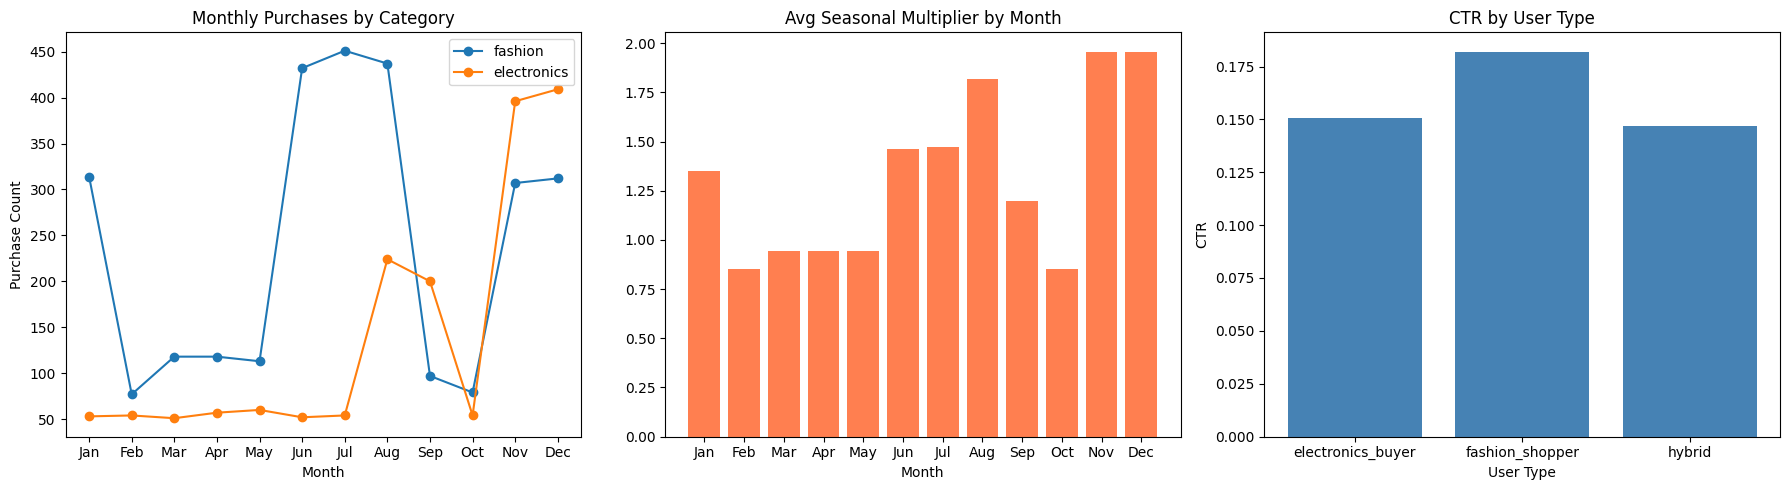

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1 — Monthly purchase volume by category
monthly = interactions[interactions['purchased'] == 1].groupby(
    ['month', 'category']
).size().reset_index(name='purchases')

for cat in ['fashion', 'electronics']:
    data = monthly[monthly['category'] == cat]
    axes[0].plot(data['month'], data['purchases'], marker='o', label=cat)

axes[0].set_title('Monthly Purchases by Category')
axes[0].set_xlabel('Month')
axes[0].set_ylabel('Purchase Count')
axes[0].set_xticks(range(1, 13))
axes[0].set_xticklabels(['Jan','Feb','Mar','Apr','May','Jun',
                          'Jul','Aug','Sep','Oct','Nov','Dec'])
axes[0].legend()

# Plot 2 — Average seasonal multiplier by month
mult_by_month = interactions.groupby('month')['seasonal_multiplier'].mean()
axes[1].bar(mult_by_month.index, mult_by_month.values, color='coral')
axes[1].set_title('Avg Seasonal Multiplier by Month')
axes[1].set_xlabel('Month')
axes[1].set_xticks(range(1, 13))
axes[1].set_xticklabels(['Jan','Feb','Mar','Apr','May','Jun',
                          'Jul','Aug','Sep','Oct','Nov','Dec'])

# Plot 3 — CTR by category (fixed)
interactions_merged = interactions.merge(users[['user_id', 'user_type']], on='user_id')
ctr = interactions_merged.groupby('user_type').apply(
    lambda x: x['clicked'].sum() / len(x)
).reset_index(name='ctr')
axes[2].bar(ctr['user_type'], ctr['ctr'], color='steelblue')
axes[2].set_title('CTR by User Type')
axes[2].set_xlabel('User Type')
axes[2].set_ylabel('CTR')

plt.tight_layout()
plt.show()

In [7]:
users.to_csv('users.csv', index=False)
products.to_csv('products.csv', index=False)
interactions.to_csv('interactions.csv', index=False)
interactions_merged.to_csv('interactions_merged.csv', index=False)

# Phase 2 — A/B Testing Engine

In [8]:
# Assign users to control / variant_a / variant_b
np.random.seed(42)

experiment_groups = np.random.choice(
    ['control', 'variant_a', 'variant_b'],
    size=N_USERS,
    p=[0.34, 0.33, 0.33]
)

users['experiment_group'] = experiment_groups

print(users['experiment_group'].value_counts())
print(users.head())

experiment_group
control      3450
variant_a    3357
variant_b    3193
Name: count, dtype: int64
  user_id          user_type  age  price_sensitivity  session_frequency  \
0  U00000    fashion_shopper   49           0.128204                 23   
1  U00001             hybrid   53           0.196043                  6   
2  U00002  electronics_buyer   54           0.594998                  5   
3  U00003  electronics_buyer   31           0.632267                 27   
4  U00004    fashion_shopper   44           0.126088                  5   

   location signup_date experiment_group  
0  Oklahoma  2024-10-24        variant_a  
1     Idaho  2023-10-22        variant_b  
2  New York  2024-04-09        variant_b  
3     Texas  2024-09-02        variant_a  
4  Missouri  2024-01-30          control  


In [9]:
# What each group experiences
experiment_config = {
    'control': {
        'recommendation': 'popularity_based',
        'discount': 0.0,
        'description': 'No discount, popularity recommendations'
    },
    'variant_a': {
        'recommendation': 'collaborative_filtering',
        'discount': 0.05,
        'description': '5% discount, collaborative filtering'
    },
    'variant_b': {
        'recommendation': 'session_aware',
        'discount': 0.10,
        'description': '10% discount, session-aware recommendations'
    }
}

for group, config in experiment_config.items():
    print(f"{group}: {config['description']}")

control: No discount, popularity recommendations
variant_a: 5% discount, collaborative filtering
variant_b: 10% discount, session-aware recommendations


In [10]:
# Merge experiment group into interactions
interactions_exp = interactions_merged.merge(
    users[['user_id', 'experiment_group']],
    on='user_id'
)

# Apply discount to purchase price based on group
discount_map = {
    'control': 0.0,
    'variant_a': 0.05,
    'variant_b': 0.10
}

interactions_exp['discount'] = interactions_exp['experiment_group'].map(discount_map)
interactions_exp['revenue'] = interactions_exp.apply(
    lambda x: x['price'] * (1 - x['discount']) if x['purchased'] == 1 else 0,
    axis=1
)

print(interactions_exp.shape)
print(interactions_exp[['user_id', 'experiment_group', 'discount', 'revenue']].head(10))

(200000, 14)
  user_id experiment_group  discount  revenue
0  U01107        variant_b      0.10      0.0
1  U05427          control      0.00      0.0
2  U05270          control      0.00      0.0
3  U06496        variant_a      0.05      0.0
4  U01687        variant_a      0.05      0.0
5  U05987        variant_b      0.10      0.0
6  U04471        variant_b      0.10      0.0
7  U05681        variant_a      0.05      0.0
8  U03475        variant_b      0.10      0.0
9  U02577        variant_a      0.05      0.0


In [11]:
from scipy import stats

def compute_metrics(df, group_col='experiment_group'):
    metrics = []
    
    for group in df[group_col].unique():
        g = df[df[group_col] == group]
        
        total_interactions = len(g)
        clicks = g['clicked'].sum()
        purchases = g['purchased'].sum()
        revenue = g['revenue'].sum()
        
        ctr = clicks / total_interactions
        conversion_rate = purchases / total_interactions
        avg_order_value = g[g['purchased'] == 1]['revenue'].mean()
        revenue_per_session = revenue / total_interactions
        
        metrics.append({
            'group': group,
            'total_interactions': total_interactions,
            'clicks': clicks,
            'purchases': purchases,
            'ctr': round(ctr, 4),
            'conversion_rate': round(conversion_rate, 4),
            'avg_order_value': round(avg_order_value, 2),
            'revenue_per_session': round(revenue_per_session, 4),
            'total_revenue': round(revenue, 2)
        })
    
    return pd.DataFrame(metrics).sort_values('group')

metrics_df = compute_metrics(interactions_exp)
print(metrics_df.to_string(index=False))

    group  total_interactions  clicks  purchases    ctr  conversion_rate  avg_order_value  revenue_per_session  total_revenue
  control               68625   12455       1841 0.1815           0.0268           157.31               4.2201      289603.43
variant_a               67616   11009       1554 0.1628           0.0230           464.83              10.6831      722349.89
variant_b               63759    9390       1124 0.1473           0.0176           468.49               8.2589      526578.78


In [12]:
def run_ab_test(df, metric='purchased'):
    control = df[df['experiment_group'] == 'control'][metric].values
    variant_a = df[df['experiment_group'] == 'variant_a'][metric].values
    variant_b = df[df['experiment_group'] == 'variant_b'][metric].values

    t_ab, p_ab = stats.ttest_ind(control, variant_a)
    t_bb, p_bb = stats.ttest_ind(control, variant_b)

    print("=" * 55)
    print("NAIVE A/B TEST RESULTS")
    print("=" * 55)
    print(f"\nControl vs Variant A:")
    print(f"  t-statistic : {t_ab:.4f}")
    print(f"  p-value     : {p_ab:.6f}")
    print(f"  Significant : {'YES' if p_ab < 0.05 else 'NO'}")

    print(f"\nControl vs Variant B:")
    print(f"  t-statistic : {t_bb:.4f}")
    print(f"  p-value     : {p_bb:.6f}")
    print(f"  Significant : {'YES' if p_bb < 0.05 else 'NO'}")

    print("\n WARNING: These results may be confounded by seasonality")
    print("=" * 55)

run_ab_test(interactions_exp)

NAIVE A/B TEST RESULTS

Control vs Variant A:
  t-statistic : 4.5516
  p-value     : 0.000005
  Significant : YES

Control vs Variant B:
  t-statistic : 11.3063
  p-value     : 0.000000
  Significant : YES



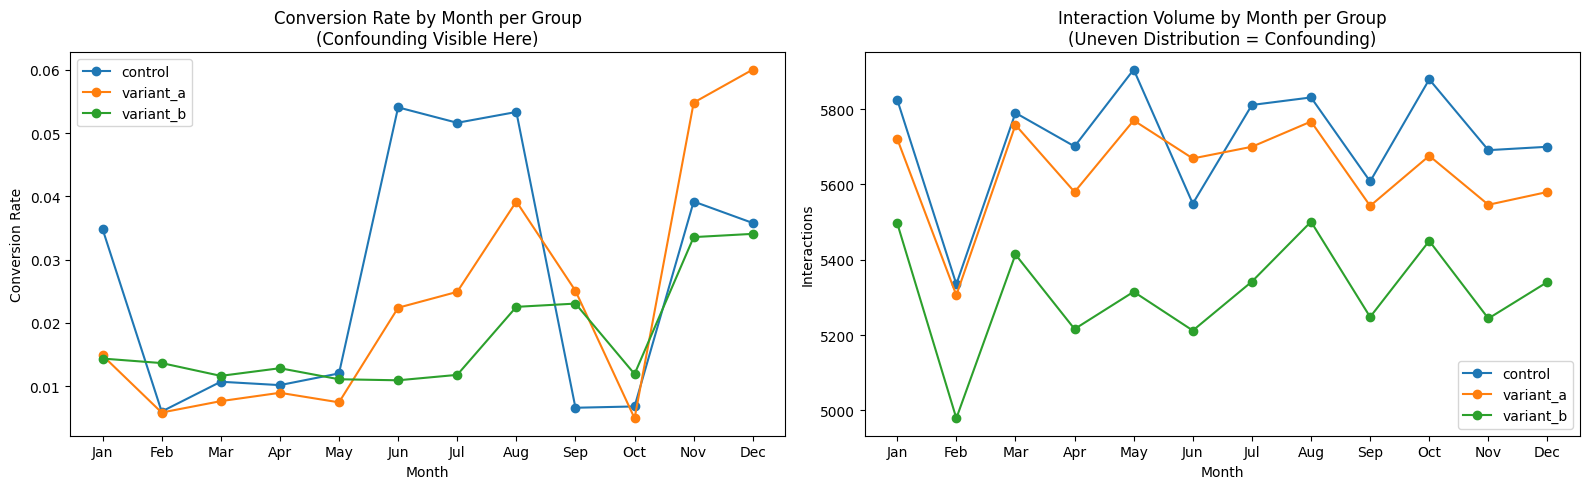

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Plot 1 — Conversion rate by month per group
monthly_conv = interactions_exp.groupby(
    ['month', 'experiment_group']
).apply(lambda x: x['purchased'].sum() / len(x)).reset_index(name='conversion_rate')

for group in ['control', 'variant_a', 'variant_b']:
    data = monthly_conv[monthly_conv['experiment_group'] == group]
    axes[0].plot(data['month'], data['conversion_rate'], marker='o', label=group)

axes[0].set_title('Conversion Rate by Month per Group\n(Confounding Visible Here)')
axes[0].set_xlabel('Month')
axes[0].set_ylabel('Conversion Rate')
axes[0].set_xticks(range(1, 13))
axes[0].set_xticklabels(['Jan','Feb','Mar','Apr','May','Jun',
                          'Jul','Aug','Sep','Oct','Nov','Dec'])
axes[0].legend()

# Plot 2 — Group interaction volume by month
monthly_vol = interactions_exp.groupby(
    ['month', 'experiment_group']
).size().reset_index(name='interactions')

for group in ['control', 'variant_a', 'variant_b']:
    data = monthly_vol[monthly_vol['experiment_group'] == group]
    axes[1].plot(data['month'], data['interactions'], marker='o', label=group)

axes[1].set_title('Interaction Volume by Month per Group\n(Uneven Distribution = Confounding)')
axes[1].set_xlabel('Month')
axes[1].set_ylabel('Interactions')
axes[1].set_xticks(range(1, 13))
axes[1].set_xticklabels(['Jan','Feb','Mar','Apr','May','Jun',
                          'Jul','Aug','Sep','Oct','Nov','Dec'])
axes[1].legend()

plt.tight_layout()
plt.show()

In [14]:
interactions_exp.to_csv('interactions_exp.csv', index=False)
metrics_df.to_csv('metrics_df.csv', index=False)

# Phase 3 — Causal Inference Layer

In [15]:
# We define the experiment as:
# Pre-period: Jan 2023 - Jun 2023
# Post-period: Jul 2023 - Dec 2023
# This lets DiD compare change across periods, not just levels

interactions_exp['date'] = pd.to_datetime(interactions_exp['date'])

interactions_exp['period'] = np.where(
    interactions_exp['date'] < datetime(2023, 7, 1),
    'pre',
    'post'
)

interactions_exp['post'] = (interactions_exp['period'] == 'post').astype(int)

# Only use 2023 data for DiD — clean pre/post split
did_data = interactions_exp[interactions_exp['date'].dt.year == 2023].copy()

print(did_data['period'].value_counts())
print(f"\nTotal interactions for DiD: {len(did_data)}")
print(did_data[['user_id', 'experiment_group', 'period', 'post', 'purchased']].head(10))

period
post    50066
pre     49539
Name: count, dtype: int64

Total interactions for DiD: 99605
   user_id experiment_group period  post  purchased
0   U01107        variant_b   post     1          0
3   U06496        variant_a    pre     0          0
7   U05681        variant_a   post     1          0
9   U02577        variant_a    pre     0          0
11  U04217        variant_a    pre     0          0
12  U06937        variant_b    pre     0          0
13  U02029        variant_a   post     1          0
15  U05958        variant_b    pre     0          0
18  U07764        variant_a    pre     0          0
19  U09939        variant_b    pre     0          0


In [16]:
print(did_data['purchased'].value_counts())
print(f"Purchase rate: {did_data['purchased'].mean():.4f}")

purchased
0    97321
1     2284
Name: count, dtype: int64
Purchase rate: 0.0229


In [17]:
import statsmodels.formula.api as smf

# DiD for Control vs Variant A
did_a = did_data[did_data['experiment_group'].isin(['control', 'variant_a'])].copy()
did_a['treated'] = (did_a['experiment_group'] == 'variant_a').astype(int)
did_a['did_interaction'] = did_a['treated'] * did_a['post']

model_a = smf.ols('purchased ~ treated + post + did_interaction', data=did_a).fit()

# DiD for Control vs Variant B
did_b = did_data[did_data['experiment_group'].isin(['control', 'variant_b'])].copy()
did_b['treated'] = (did_b['experiment_group'] == 'variant_b').astype(int)
did_b['did_interaction'] = did_b['treated'] * did_b['post']

model_b = smf.ols('purchased ~ treated + post + did_interaction', data=did_b).fit()

print("=" * 55)
print("DIFFERENCE-IN-DIFFERENCES RESULTS")
print("=" * 55)

print("\nControl vs Variant A:")
print(f"  DiD Estimate : {model_a.params['did_interaction']:.6f}")
print(f"  p-value      : {model_a.pvalues['did_interaction']:.6f}")
print(f"  Significant  : {'YES' if model_a.pvalues['did_interaction'] < 0.05 else 'NO'}")

print("\nControl vs Variant B:")
print(f"  DiD Estimate : {model_b.params['did_interaction']:.6f}")
print(f"  p-value      : {model_b.pvalues['did_interaction']:.6f}")
print(f"  Significant  : {'YES' if model_b.pvalues['did_interaction'] < 0.05 else 'NO'}")

print("\n" + "=" * 55)
print("NAIVE A/B said: Control wins, both variants worse")
print("DiD says: See above — true causal effect revealed")
print("=" * 55)

DIFFERENCE-IN-DIFFERENCES RESULTS

Control vs Variant A:
  DiD Estimate : 0.013743
  p-value      : 0.000000
  Significant  : YES

Control vs Variant B:
  DiD Estimate : -0.001377
  p-value      : 0.552665
  Significant  : NO

NAIVE A/B said: Control wins, both variants worse
DiD says: See above — true causal effect revealed


In [18]:
pip install statsmodels

Note: you may need to restart the kernel to use updated packages.


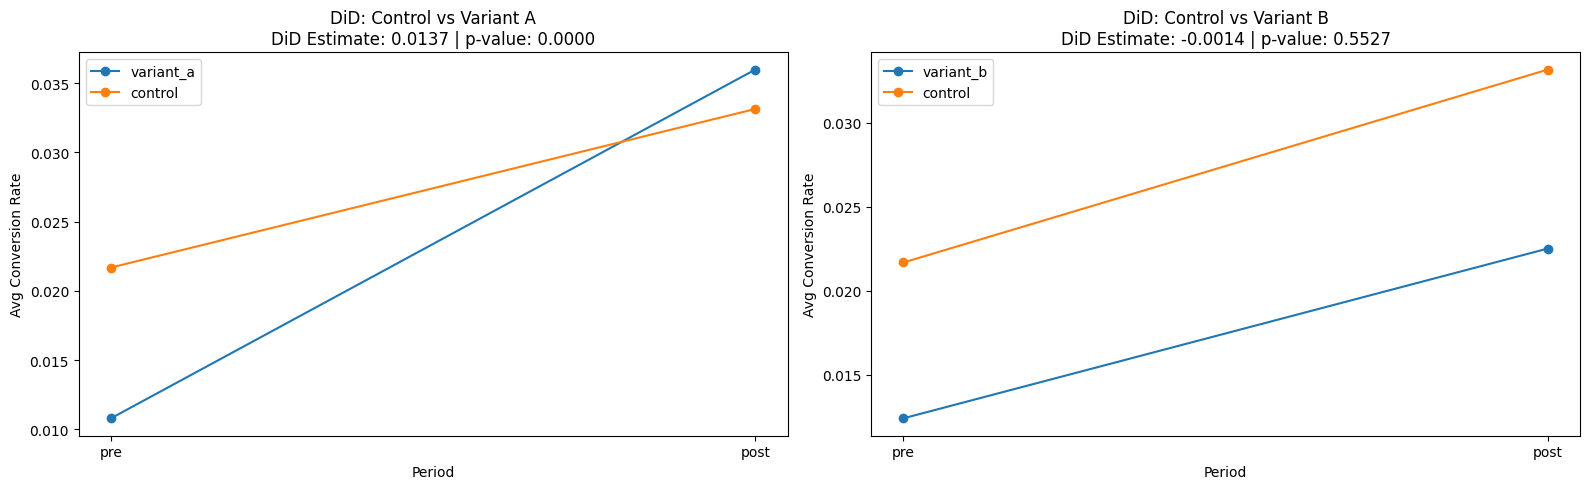

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, (variant, did_df, model) in zip(axes, [
    ('Variant A', did_a, model_a),
    ('Variant B', did_b, model_b)
]):
    summary = did_df.groupby(['period', 'experiment_group'])['purchased'].mean().reset_index()
    
    for group in did_df['experiment_group'].unique():
        data = summary[summary['experiment_group'] == group]
        data = data.sort_values('period', ascending=False)
        ax.plot(data['period'], data['purchased'], marker='o', label=group)
    
    did_est = model.params['did_interaction']
    p_val = model.pvalues['did_interaction']
    
    ax.set_title(f'DiD: Control vs {variant}\nDiD Estimate: {did_est:.4f} | p-value: {p_val:.4f}')
    ax.set_xlabel('Period')
    ax.set_ylabel('Avg Conversion Rate')
    ax.legend()

plt.tight_layout()
plt.show()

In [20]:
# Build monthly conversion rates per group for synthetic control
sc_data = interactions_exp[interactions_exp['date'].dt.year == 2023].copy()

monthly_metrics = sc_data.groupby(
    ['month', 'experiment_group']
).agg(
    conversion_rate=('purchased', 'mean'),
    total_interactions=('purchased', 'count'),
    total_purchases=('purchased', 'sum')
).reset_index()

# Pivot — each group becomes a column
sc_pivot = monthly_metrics.pivot(
    index='month',
    columns='experiment_group',
    values='conversion_rate'
).reset_index()

sc_pivot.columns.name = None
print(sc_pivot)

    month   control  variant_a  variant_b
0       1  0.032080   0.014225   0.011615
1       2  0.006068   0.006077   0.013003
2       3  0.011571   0.006413   0.014438
3       4  0.009398   0.009246   0.010510
4       5  0.009479   0.007284   0.013973
5       6  0.060723   0.021186   0.011022
6       7  0.054314   0.024608   0.011073
7       8  0.056908   0.042428   0.021392
8       9  0.007824   0.025335   0.022357
9      10  0.008585   0.004500   0.012079
10     11  0.038214   0.054173   0.031648
11     12  0.032315   0.065655   0.037165


In [21]:
from scipy.optimize import minimize

# Use pre-period (months 1-6) to find optimal weights
# that make synthetic control match variant_a pre-treatment
pre_period = sc_pivot[sc_pivot['month'] <= 6]
post_period = sc_pivot[sc_pivot['month'] > 6]

# Donor pool — control and variant_b are donors
# We construct synthetic variant_a from their weighted combination
donor_pre = pre_period[['control', 'variant_b']].values
treated_pre = pre_period['variant_a'].values

# Optimize weights — minimize distance between synthetic and treated in pre-period
def loss(weights):
    synthetic = donor_pre @ weights
    return np.sum((synthetic - treated_pre) ** 2)

constraints = {'type': 'eq', 'fun': lambda w: np.sum(w) - 1}
bounds = [(0, 1), (0, 1)]
init_weights = [0.5, 0.5]

result = minimize(loss, init_weights, bounds=bounds, constraints=constraints)
weights = result.x

print(f"Synthetic Control Weights:")
print(f"  Control weight   : {weights[0]:.4f}")
print(f"  Variant B weight : {weights[1]:.4f}")
print(f"  Optimization success: {result.success}")

Synthetic Control Weights:
  Control weight   : 0.2228
  Variant B weight : 0.7772
  Optimization success: True


In [22]:
# Build full synthetic series across all months
donor_all = sc_pivot[['control', 'variant_b']].values
synthetic_a = donor_all @ weights

sc_pivot['synthetic_a'] = synthetic_a
sc_pivot['gap'] = sc_pivot['variant_a'] - sc_pivot['synthetic_a']

print(sc_pivot[['month', 'variant_a', 'synthetic_a', 'gap']].to_string(index=False))
print(f"\nAvg gap pre-treatment  (months 1-6) : {sc_pivot[sc_pivot['month'] <= 6]['gap'].mean():.6f}")
print(f"Avg gap post-treatment (months 7-12): {sc_pivot[sc_pivot['month'] > 6]['gap'].mean():.6f}")

 month  variant_a  synthetic_a       gap
     1   0.014225     0.016175 -0.001951
     2   0.006077     0.011457 -0.005381
     3   0.006413     0.013799 -0.007386
     4   0.009246     0.010262 -0.001016
     5   0.007284     0.012971 -0.005687
     6   0.021186     0.022097 -0.000911
     7   0.024608     0.020708  0.003899
     8   0.042428     0.029306  0.013122
     9   0.025335     0.019119  0.006216
    10   0.004500     0.011301 -0.006801
    11   0.054173     0.033111  0.021062
    12   0.065655     0.036084  0.029571

Avg gap pre-treatment  (months 1-6) : -0.003722
Avg gap post-treatment (months 7-12): 0.011178


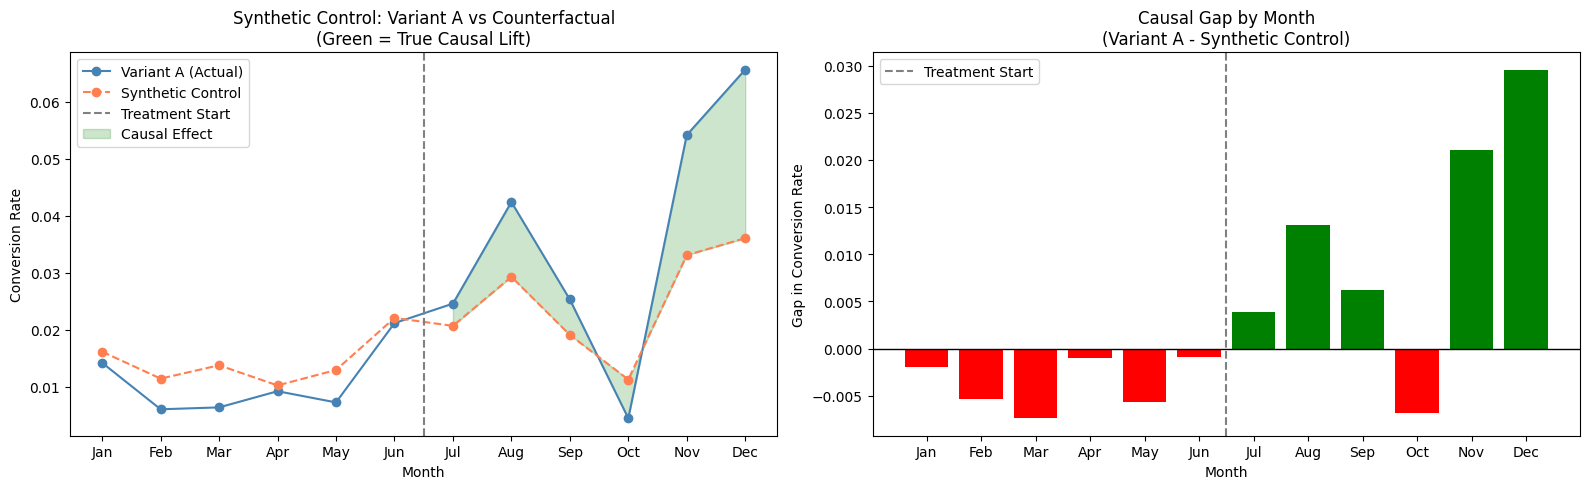

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Plot 1 — Actual vs Synthetic
axes[0].plot(sc_pivot['month'], sc_pivot['variant_a'], 
             marker='o', label='Variant A (Actual)', color='steelblue')
axes[0].plot(sc_pivot['month'], sc_pivot['synthetic_a'], 
             marker='o', linestyle='--', label='Synthetic Control', color='coral')
axes[0].axvline(x=6.5, color='gray', linestyle='--', linewidth=1.5, label='Treatment Start')
axes[0].fill_between(
    sc_pivot['month'],
    sc_pivot['synthetic_a'],
    sc_pivot['variant_a'],
    where=sc_pivot['month'] > 6,
    alpha=0.2, color='green', label='Causal Effect'
)
axes[0].set_title('Synthetic Control: Variant A vs Counterfactual\n(Green = True Causal Lift)')
axes[0].set_xlabel('Month')
axes[0].set_ylabel('Conversion Rate')
axes[0].set_xticks(range(1, 13))
axes[0].set_xticklabels(['Jan','Feb','Mar','Apr','May','Jun',
                          'Jul','Aug','Sep','Oct','Nov','Dec'])
axes[0].legend()

# Plot 2 — Gap plot
axes[1].bar(sc_pivot['month'], sc_pivot['gap'], 
            color=np.where(sc_pivot['gap'] > 0, 'green', 'red'))
axes[1].axhline(y=0, color='black', linewidth=1)
axes[1].axvline(x=6.5, color='gray', linestyle='--', linewidth=1.5, label='Treatment Start')
axes[1].set_title('Causal Gap by Month\n(Variant A - Synthetic Control)')
axes[1].set_xlabel('Month')
axes[1].set_ylabel('Gap in Conversion Rate')
axes[1].set_xticks(range(1, 13))
axes[1].set_xticklabels(['Jan','Feb','Mar','Apr','May','Jun',
                          'Jul','Aug','Sep','Oct','Nov','Dec'])
axes[1].legend()

plt.tight_layout()
plt.show()

In [24]:
sc_pivot.to_csv('synthetic_control.csv', index=False)
interactions_exp.to_csv('interactions_exp_final.csv', index=False)

In [25]:
users.to_csv('users.csv', index=False)
print("Users resaved with experiment_group column.")

Users resaved with experiment_group column.
